In [296]:
# import data
import os
from datasets import load_dataset

# basic
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import re
from tqdm import tqdm

# pre-processing
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV, RandomizedSearchCV, cross_val_predict, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

# model
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error
from itertools import combinations
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.base import BaseEstimator, RegressorMixin


# PART 1. Data Pre-processing

#### 1. Load data

In [98]:
# load data from Hugging face
ds = load_dataset("aneesarom/Food-Delivery")

# convert to dataframe
df = pd.concat([ds['train'].to_pandas(), ds['test'].to_pandas()], ignore_index=True)

# sanity check
print(df.shape)
df.head()

(45584, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0x6bbb,INDORES02DEL01,23.0,4.5,22.651847,75.881991,22.721847,75.951991,18-03-2022,22:10,22:25,Stormy,Low,1,Buffet,motorcycle,1.0,No,Metropolitian,17
1,0x190a,MYSRES20DEL01,39.0,4.3,12.337978,76.616792,12.377978,76.656792,17-03-2022,15:10,15:20,Cloudy,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,33
2,0x120c,MYSRES07DEL02,37.0,4.8,12.325461,76.632278,12.375461,76.682278,03-03-2022,23:55,24:10:00,Windy,Low,2,Meal,scooter,0.0,No,NaN,20
3,0x6016,SURRES12DEL03,30.0,4.8,21.183434,72.814492,21.213434,72.844492,05-03-2022,17:35,17:40,Sandstorms,Medium,0,Snack,motorcycle,0.0,No,Metropolitian,27
4,0x9ca0,VADRES13DEL02,29.0,4.6,22.310237,73.158921,22.360237,73.208921,11-03-2022,21:30,21:45,Cloudy,Jam,2,Buffet,scooter,0.0,No,Metropolitian,26


#### 2. Format Conversion

In [99]:
# 1. check all columns info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45584 entries, 0 to 45583
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45584 non-null  str    
 1   Delivery_person_ID           45584 non-null  str    
 2   Delivery_person_Age          43730 non-null  float64
 3   Delivery_person_Ratings      43676 non-null  float64
 4   Restaurant_latitude          45584 non-null  float64
 5   Restaurant_longitude         45584 non-null  float64
 6   Delivery_location_latitude   45584 non-null  float64
 7   Delivery_location_longitude  45584 non-null  float64
 8   Order_Date                   45584 non-null  str    
 9   Time_Orderd                  43853 non-null  str    
 10  Time_Order_picked            45584 non-null  str    
 11  Weather_conditions           44968 non-null  str    
 12  Road_traffic_density         44983 non-null  str    
 13  Vehicle_condition          

In [100]:
# 2. Convert date format
# Convert Order_Date (format: DD-MM-YYYY) to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y', errors='coerce')

# Check how many failed to convert (became NaT)
print(f"Order_Date NaT count: {df['Order_Date'].isnull().sum()}")

Order_Date NaT count: 0


In [101]:
# 3. Convert time format
# Check if any time format is out of pattern HH:MM
pattern = re.compile(r'^\d{2}:\d{2}$')

def check_suspicious_times(df, column):
    value_counts = df[column].value_counts(dropna=False)
    suspicious_counts = value_counts[~value_counts.index.astype(str).str.match(pattern)]
    print(f"--- {column} ---")
    print(suspicious_counts)
    print(f"Total suspicious rows: {suspicious_counts.sum()}\n")
    return suspicious_counts

check_suspicious_times(df, 'Time_Orderd')
check_suspicious_times(df, 'Time_Order_picked')

--- Time_Orderd ---
Time_Orderd
NaN            1731
0.833333333     449
1               430
0.791666667     424
0.958333333     422
0.875           409
0.916666667     404
0.75            402
0.416666667     211
0.458333333     193
0.5             189
0.375           177
0.625            86
0.541666667      79
0.583333333      74
0.708333333      66
0.666666667      53
Name: count, dtype: int64
Total suspicious rows: 5799

--- Time_Order_picked ---
Time_Order_picked
0.833333333    452
1              440
24:05:00       435
0.916666667    430
0.75           422
0.875          416
0.958333333    411
0.791666667    403
24:10:00       280
0.375          201
0.416666667    194
0.5            188
24:15:00       165
0.458333333    148
0.625          100
0.666666667     91
0.541666667     83
0.583333333     82
0.708333333     66
Name: count, dtype: int64
Total suspicious rows: 5007



Time_Order_picked
0.833333333    452
1              440
24:05:00       435
0.916666667    430
0.75           422
0.875          416
0.958333333    411
0.791666667    403
24:10:00       280
0.375          201
0.416666667    194
0.5            188
24:15:00       165
0.458333333    148
0.625          100
0.666666667     91
0.541666667     83
0.583333333     82
0.708333333     66
Name: count, dtype: int64

In [102]:
# function to parse time 
def parse_time_value(val):
    if pd.isnull(val):
        return pd.NaT
    
    if isinstance(val, str):
        val = val.strip()
        if val.lower() == 'nan' or val == '':
            return pd.NaT
    
    # Try parsing as Excel-style fraction of a day (numeric), valid range [0, 1]
    try:
        frac = float(val)
        if 0 <= frac <= 1:
            total_seconds = round(frac * 24 * 3600)
            rollover_days = total_seconds // (24 * 3600)  # 1 if frac == 1.0, else 0
            hours = (total_seconds // 3600) % 24
            minutes = (total_seconds % 3600) // 60
            base = pd.to_datetime(f"{hours:02d}:{minutes:02d}", format='%H:%M', errors='coerce')
            return base + pd.Timedelta(days=rollover_days)
        else:
            return pd.NaT
    except (ValueError, TypeError):
        pass
    
    # Try HH:MM:SS strings with hour possibly = 24 (roll over to next day, 00:xx)
    match = re.match(r'^(\d{2}):(\d{2}):(\d{2})$', val)
    if match:
        h, m, s = int(match.group(1)), int(match.group(2)), int(match.group(3))
        rollover_days = h // 24  # 1 if h == 24, else 0
        h = h % 24
        base = pd.to_datetime(f"{h:02d}:{m:02d}", format='%H:%M', errors='coerce')
        return base + pd.Timedelta(days=rollover_days)
    
    # Otherwise, try parsing as a normal HH:MM string
    return pd.to_datetime(val, format='%H:%M', errors='coerce')

df['Time_Ordered'] = df['Time_Orderd'].apply(parse_time_value)
df['Time_Order_Picked'] = df['Time_Order_picked'].apply(parse_time_value)

print(f"Time_Ordered NaT count: {df['Time_Ordered'].isnull().sum()}")
print(f"Time_Order_Picked NaT count: {df['Time_Order_Picked'].isnull().sum()}")

Time_Ordered NaT count: 1731
Time_Order_Picked NaT count: 0


#### 3. Missing values

In [103]:
# 1. Check overall NA counts first
# Replace any NaN string to NA
df = df.replace('NaN', np.nan)

# Check missing value counts
df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weather_conditions              616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken (min)                  0
Time_Ordered                   1731
Time_Order_Picked                 0
dtype: int64

In [104]:
# 2. check values of string columns
# cols = ['Weather_conditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']
# for x in cols:
#     print(f"--- {x} ---")
#     print(df[x].value_counts(dropna=False).to_string())
#     print()

# print(df['Weather_conditions'].value_counts(dropna=False).to_string())
# print(df['Road_traffic_density'].value_counts(dropna=False).to_string())
# print(df['Type_of_order'].value_counts(dropna=False).to_string())
# print(df['Type_of_vehicle'].value_counts(dropna=False).to_string())
# print(df['Festival'].value_counts(dropna=False).to_string())
# print(df['City'].value_counts(dropna=False).to_string())

In [105]:
# 3. Remove missing values
# Remove missing values
df_clean = df.dropna()

# sanity check
print(f"Original shape: {df.shape}")
print(f"After dropping missing values: {df_clean.shape}")

# print all columns info
df_clean.info()

Original shape: (45584, 22)
After dropping missing values: (41359, 22)
<class 'pandas.DataFrame'>
Index: 41359 entries, 0 to 45583
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           41359 non-null  str           
 1   Delivery_person_ID           41359 non-null  str           
 2   Delivery_person_Age          41359 non-null  float64       
 3   Delivery_person_Ratings      41359 non-null  float64       
 4   Restaurant_latitude          41359 non-null  float64       
 5   Restaurant_longitude         41359 non-null  float64       
 6   Delivery_location_latitude   41359 non-null  float64       
 7   Delivery_location_longitude  41359 non-null  float64       
 8   Order_Date                   41359 non-null  datetime64[us]
 9   Time_Orderd                  41359 non-null  str           
 10  Time_Order_picked            41359 non-null  str   

In [106]:
# Check duplicates
print(f"Number of duplicate rows: {df_clean.duplicated().sum()}")

Number of duplicate rows: 0


#### 4. Feature Engineering

In [107]:
# 1. Calculate distance
# Function to calculate Haversine distance
def haversine_np(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371 * c  # km

# Distance in km
df_clean['Distance_km'] = haversine_np(df_clean['Restaurant_latitude'],
                                         df_clean['Restaurant_longitude'],
                                         df_clean['Delivery_location_latitude'],
                                         df_clean['Delivery_location_longitude'])

# sanity check
df_clean['Distance_km'].describe()

count    41359.000000
mean        26.915498
std        298.814439
min          1.465067
25%          4.663601
50%          9.268782
75%         13.735954
max       6884.726399
Name: Distance_km, dtype: float64

In [108]:
# 2. Calculate preparation in minutes
# calculate prep time
df_clean['Prep_time_min'] = (
    df_clean['Time_Order_Picked'] - df_clean['Time_Ordered']
    ).dt.total_seconds() / 60

# sanity check
df_clean['Prep_time_min'].describe()

count    41359.000000
mean         9.988999
std          4.086094
min          5.000000
25%          5.000000
50%         10.000000
75%         15.000000
max         15.000000
Name: Prep_time_min, dtype: float64

#### 5. Data Split

In [109]:
# target
y = df_clean['Time_taken (min)']

# X
X = df_clean.drop(columns=['ID',
                            'Delivery_person_ID',
                            'Order_Date',
                            'Time_Orderd',
                            'Time_Order_picked',
                            'Restaurant_latitude',
                            'Restaurant_longitude',
                            'Delivery_location_latitude',
                            'Delivery_location_longitude',
                            'Time_taken (min)',
                            'Time_Ordered',
                            'Time_Order_Picked'])

# sanity check
print('Target:', y.shape)
print('No of features:', X.shape)

Target: (41359,)
No of features: (41359, 12)


In [110]:
# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 33087
Test size: 8272


#### 6. Data Patterns

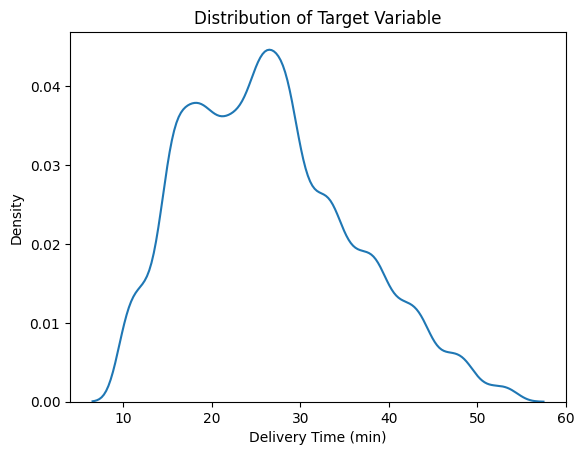

In [111]:
# 1. Distribution of target variable
sns.kdeplot(y_train)
plt.xlabel('Delivery Time (min)')
plt.title('Distribution of Target Variable')
plt.show()

In [112]:
# features
feature_labels = X_train.columns
cat_cols = ['Weather_conditions', 'Road_traffic_density', 'Vehicle_condition',
            'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 
            'Festival', 'City']
num_cols = [x for x in feature_labels if x not in cat_cols]

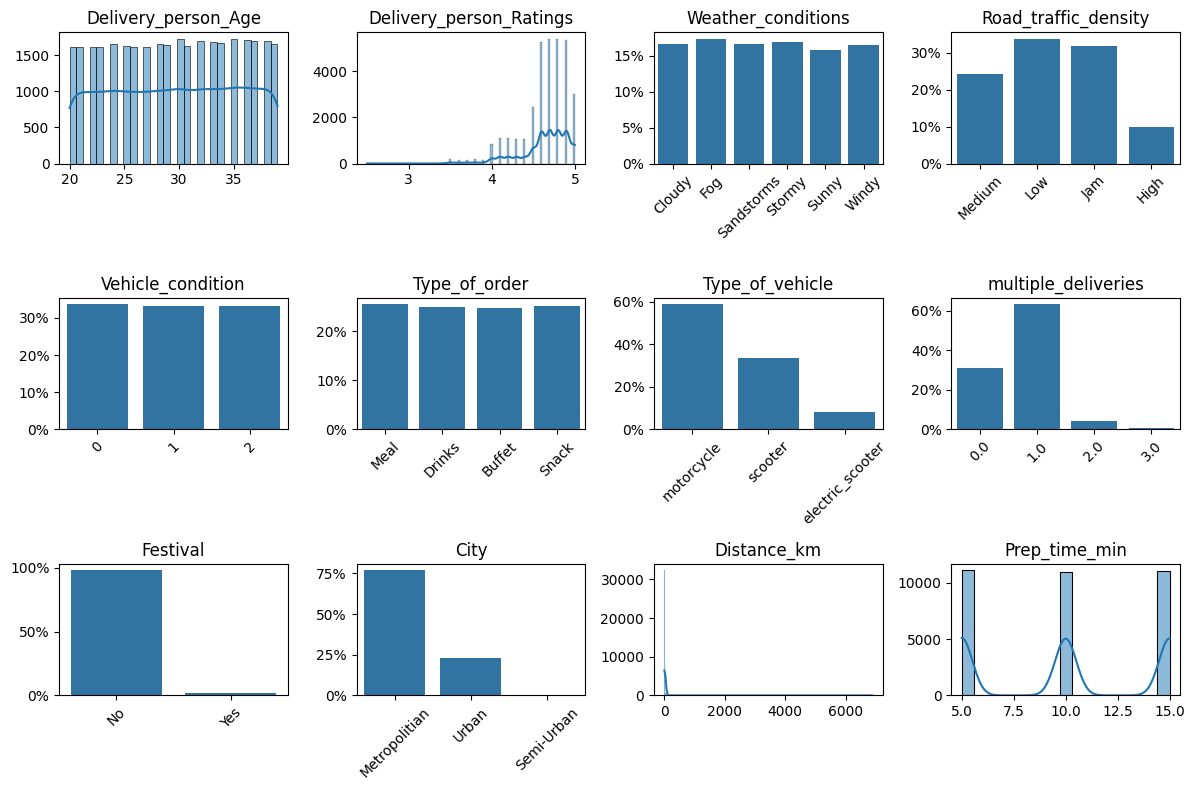

In [113]:
# 2. Distribution of feature variables
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 8))
axes = axes.flatten()

# histogram: numerical + count plots: categorical
for i, col in enumerate(feature_labels):
  if col in cat_cols:
    sns.countplot(x=col, data=X_train, ax=axes[i], stat='percent')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].yaxis.set_major_formatter(PercentFormatter(decimals=0))
  else:
    sns.histplot(X_train[col], ax=axes[i], kde=True)

  axes[i].set_title(col)
  axes[i].set_xlabel('')
  axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

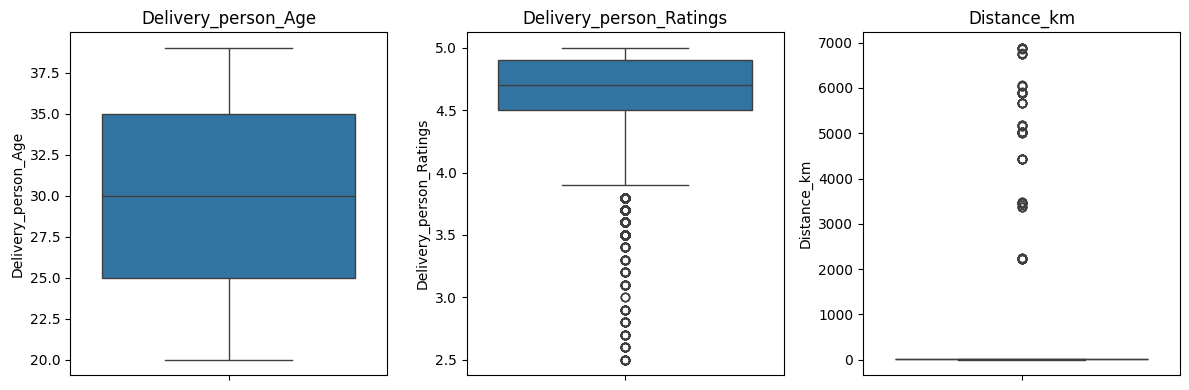

In [114]:
# Box plots of numerical
fig, axes = plt.subplots(1, 3, figsize=(12,4))
for k, col in enumerate(num_cols):
    if col != 'Prep_time_min':
        sns.boxplot(y=X_train[col], ax=axes[k])
        axes[k].set_title(col)

plt.tight_layout()
plt.show()

#### 7. Outliers

In [115]:
# Review Distance_km
print("Basic statistics of Distance_km:")
print(X_train['Distance_km'].describe())

# Calculate mean +/- 3 std
mean = X_train['Distance_km'].mean()
std = X_train['Distance_km'].std()
print("\n\nMean +/- 3 std of Distance_km:")
print(mean - 3 * std, mean + 3 * std)

# count for outliers
print("Number of outliers (> mean+3std):", (X_train['Distance_km'] >= mean + 3 * std).sum())
print("Account for:",((X_train['Distance_km'] >= mean + 3 * std).sum() / len(X_train['Distance_km']))*100)


# IQR
Q1 = X_train['Distance_km'].quantile(0.25)
Q3 = X_train['Distance_km'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\n\nLower bound and Upper bound:")
print(lower_bound, upper_bound)

# count number of Distance_km more than upper_bound
print("Number of outliers (> upper_bound):", (X_train['Distance_km'] >= upper_bound).sum())
print("Account for:",((X_train['Distance_km'] >= upper_bound).sum() / len(X_train['Distance_km']))*100)

Basic statistics of Distance_km:
count    33087.000000
mean        26.896662
std        300.023128
min          1.465067
25%          4.663456
50%          9.220835
75%         13.682379
max       6884.726399
Name: Distance_km, dtype: float64


Mean +/- 3 std of Distance_km:
-873.1727229723627 926.9660478063591
Number of outliers (> mean+3std): 116
Account for: 0.3505908665034606


Lower bound and Upper bound:
-8.864927740322289 27.21076284656931
Number of outliers (> upper_bound): 116
Account for: 0.3505908665034606


In [116]:
# filter out outliers
idx_train = (X_train['Distance_km'] >= lower_bound) & (X_train['Distance_km'] <= upper_bound)

# training
X_train_clean = X_train[idx_train]
y_train_clean = y_train[idx_train]

print(f"Removed {(~idx_train).sum()} outlier rows out of {len(X_train)} training rows")
print(f"X_train_clean shape: {X_train_clean.shape}")
print(f"y_train_clean shape: {y_train_clean.shape}")

# test
idx_test = (X_test['Distance_km'] >= lower_bound) & (X_test['Distance_km'] <= upper_bound)
X_test_clean = X_test[idx_test]
y_test_clean = y_test[idx_test]

print(f"Removed {(~idx_test).sum()} outlier rows out of {len(X_test)} testing rows")
print(f"X_test_clean shape: {X_test_clean.shape}")
print(f"y_test_clean shape: {y_test_clean.shape}")


Removed 116 outlier rows out of 33087 training rows
X_train_clean shape: (32971, 12)
y_train_clean shape: (32971,)
Removed 30 outlier rows out of 8272 testing rows
X_test_clean shape: (8242, 12)
y_test_clean shape: (8242,)


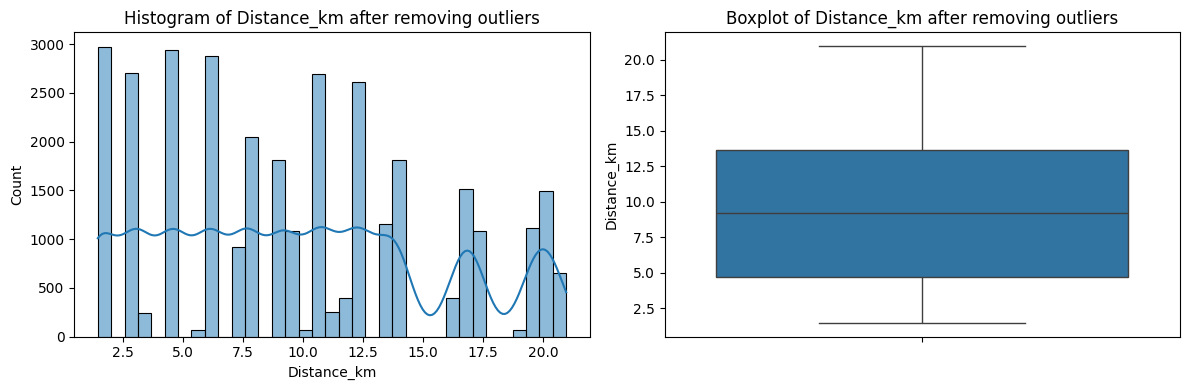

In [117]:
# Visual check: distribution
fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.histplot(X_train_clean['Distance_km'], kde=True, ax=axes[0])
axes[0].set_title('Histogram of Distance_km after removing outliers')

sns.boxplot(y=X_train_clean['Distance_km'], ax=axes[1])
axes[1].set_title('Boxplot of Distance_km after removing outliers')

plt.tight_layout()
plt.show()

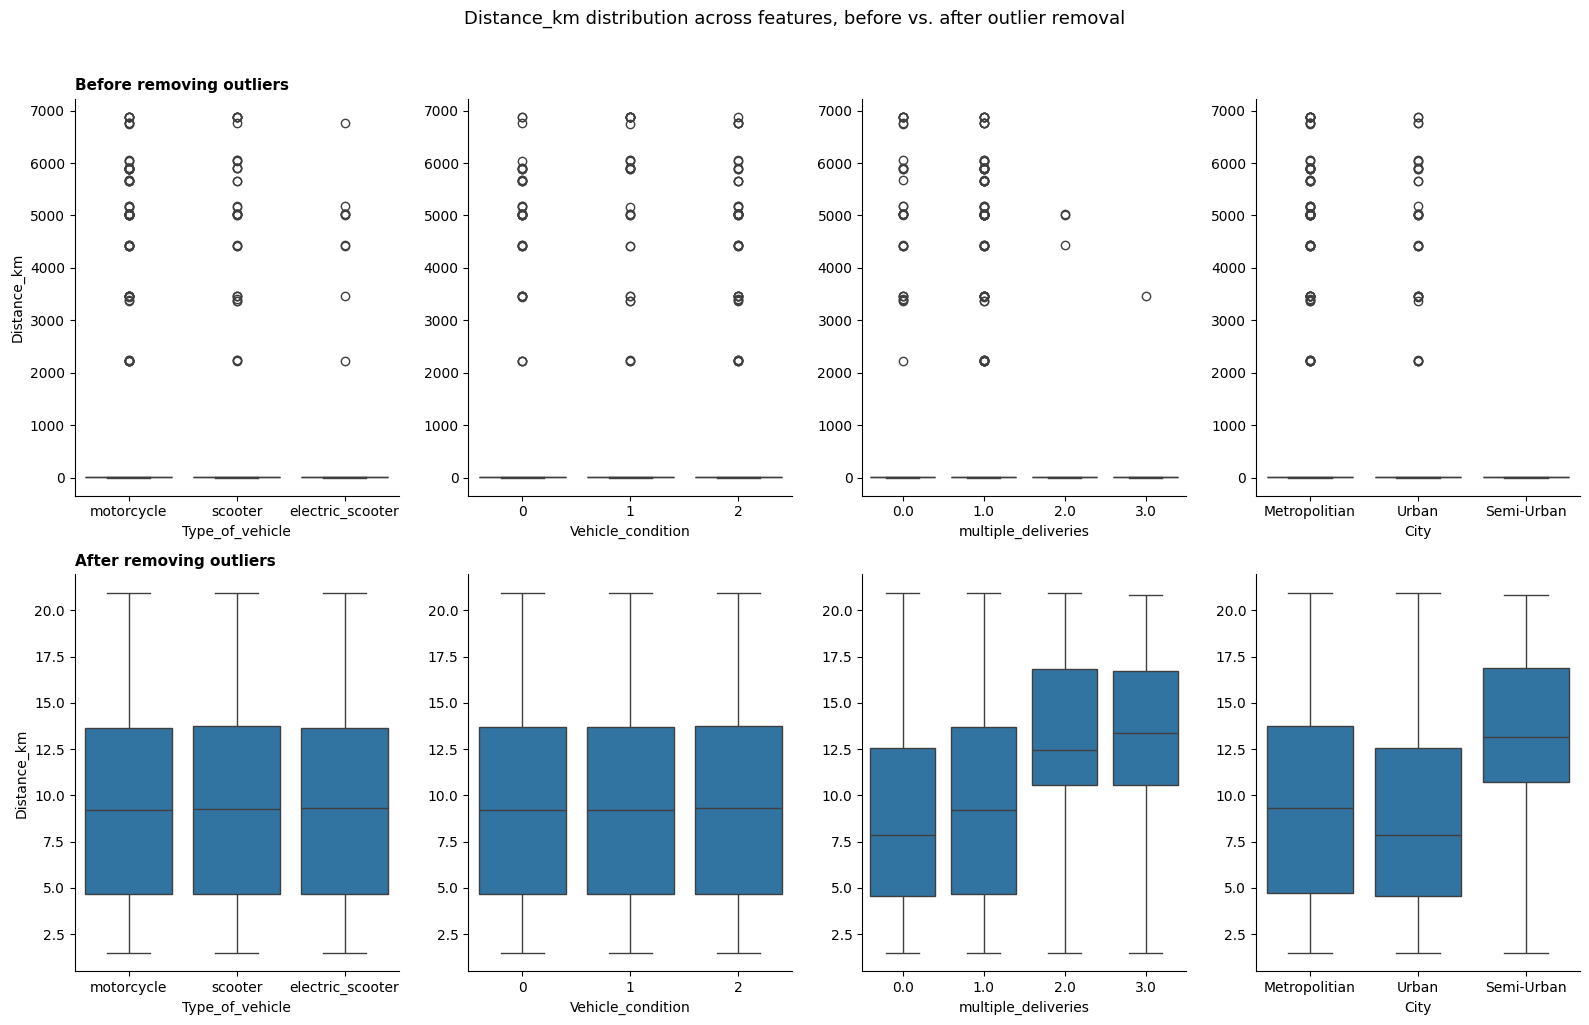

In [118]:
# Visual check: Distance_km vs. other features
fig, axes = plt.subplots(2,4, figsize=(16,10))

datasets = {'X_train': X_train, 'X_train_clean': X_train_clean}
feat_name = ['Type_of_vehicle', 'Vehicle_condition', 'multiple_deliveries', 'City']

for row, (name, df) in enumerate(datasets.items()):
    for col, feat in enumerate(feat_name):
        sns.boxplot(data=df, x=feat, y='Distance_km', ax=axes[row, col])
        if col == 0:
            axes[row, col].set_ylabel('Distance_km')
        else:
            axes[row, col].set_ylabel('')
        # remove top/right spines for a cleaner look
        axes[row, col].spines['top'].set_visible(False)
        axes[row, col].spines['right'].set_visible(False)

axes[0, 0].set_title('Before removing outliers', fontsize=11, fontweight='bold', loc='left')
axes[1, 0].set_title('After removing outliers', fontsize=11, fontweight='bold', loc='left')

fig.suptitle('Distance_km distribution across features, before vs. after outlier removal', 
             fontsize=13, y=1.02)

plt.tight_layout()
plt.show()

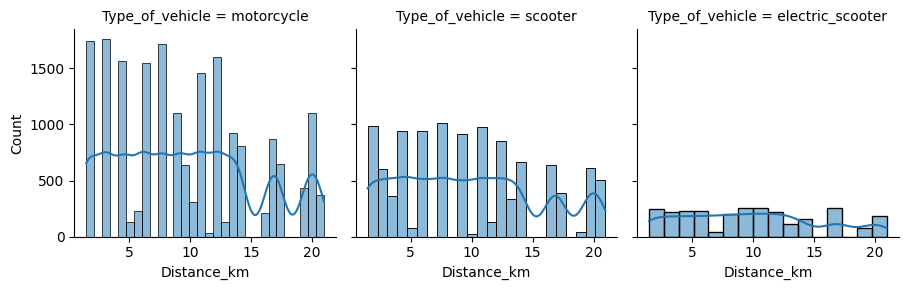

In [119]:
g = sns.FacetGrid(X_train_clean, col='Type_of_vehicle', col_wrap=4)
g.map(sns.histplot, 'Distance_km', kde=True)
plt.show()

#### 8. EDA

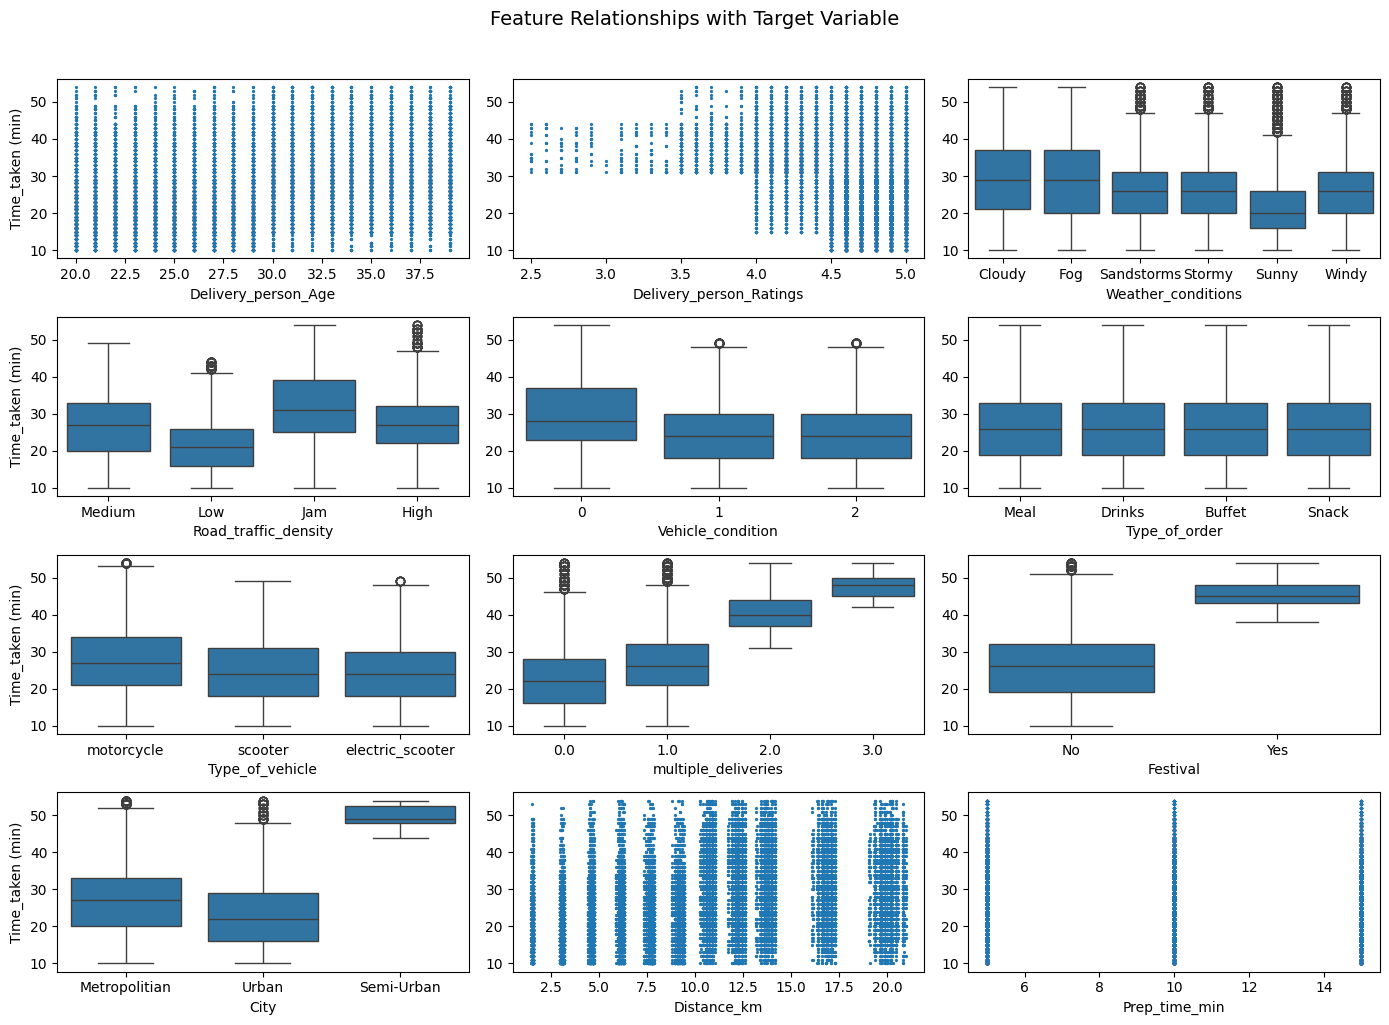

In [120]:
# 1. Cross plot: feature vs. target relationships
fig, axs = plt.subplots(4, 3, figsize=(14, 10))
axs = axs.flatten()

for k, feat in enumerate(feature_labels):

    if feat in cat_cols:
        sns.boxplot(x=X_train_clean[feat], y=y_train_clean, ax=axs[k])
    else:
        axs[k].scatter(X_train_clean[feat], y_train_clean, marker='.', s=7.0)
    
    axs[k].set_xlabel(feat)
    if k % 3 == 0:
        axs[k].set_ylabel(y_train.name)
    else:
        axs[k].set_ylabel('')

fig.suptitle('Feature Relationships with Target Variable', fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

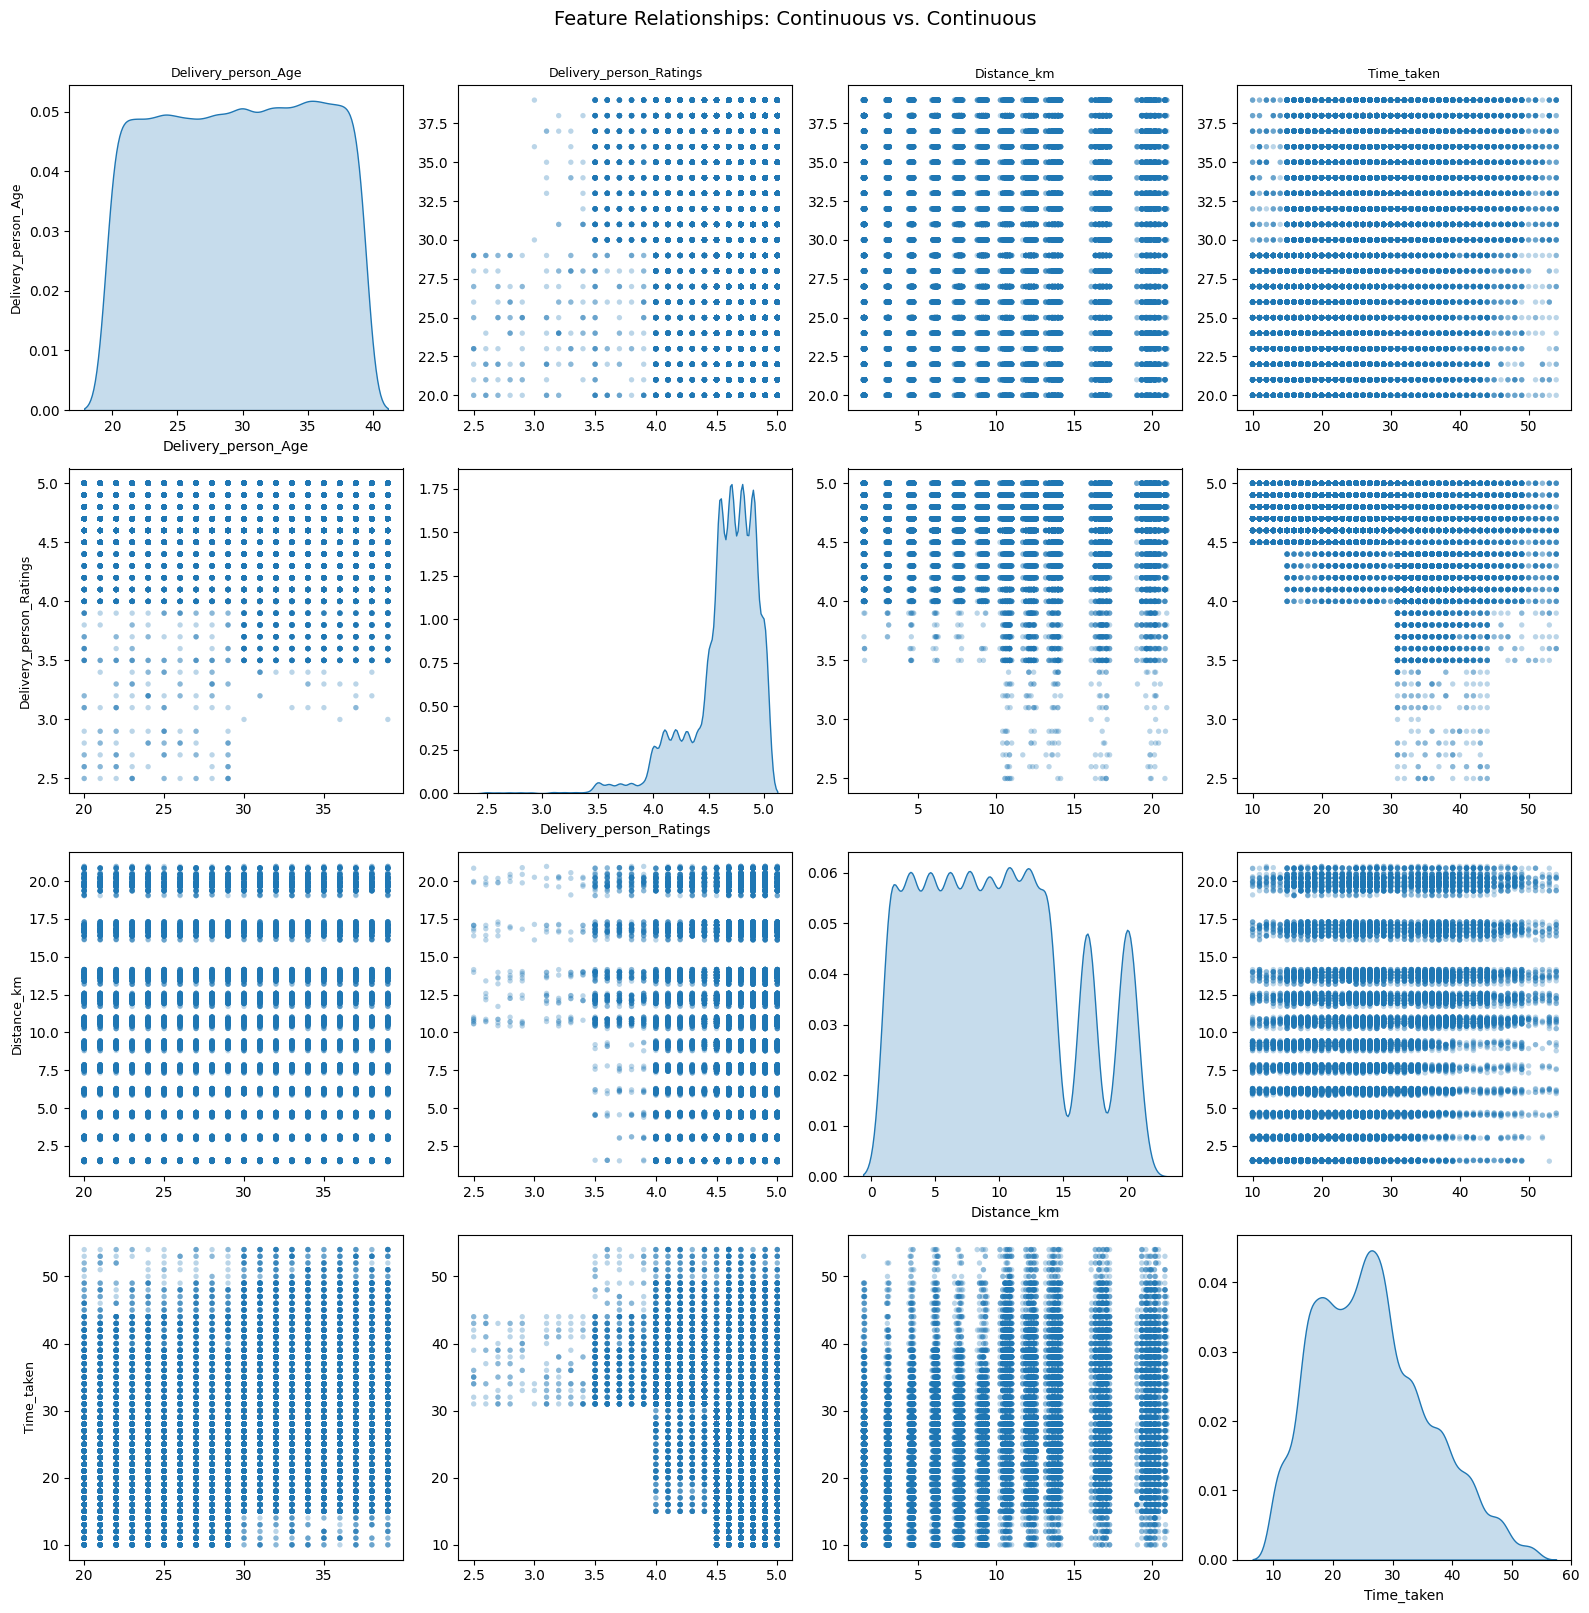

In [121]:
# 2. Pair plot: feature vs. feature relationships
# Combine X_train and y_train into one DataFrame
train_df = X_train_clean.copy()
train_df['Time_taken'] = y_train_clean

continuous_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Distance_km', 'Time_taken']
discrete_cols = ['Vehicle_condition', 'multiple_deliveries', 'Prep_time_min']
categorical_cols = ['Weather_conditions', 'Type_of_order', 'City', 'Festival', 'Road_traffic_density']

n_cont = len(continuous_cols)
n_disc = len(discrete_cols)
n_cat = len(categorical_cols)

# Pair plots
# Figure 1: Continuous vs Continuous (manual pairplot grid)
fig, axs = plt.subplots(n_cont, n_cont, figsize=(4*n_cont, 4*n_cont))

for row, rcol in enumerate(continuous_cols):
    for col, ccol in enumerate(continuous_cols):
        ax = axs[row, col]
        if row == col:
            sns.kdeplot(train_df[rcol], ax=ax, fill=True)
            ax.set_ylabel('')
        else:
            ax.scatter(train_df[ccol], train_df[rcol], alpha=0.3, s=15, edgecolor='none')
        if row == 0:
            ax.set_title(ccol, fontsize=9)
        if col == 0:
            ax.set_ylabel(rcol, fontsize=9)

fig.suptitle('Feature Relationships: Continuous vs. Continuous', y=1.005, fontsize=14)
plt.tight_layout()
plt.show()

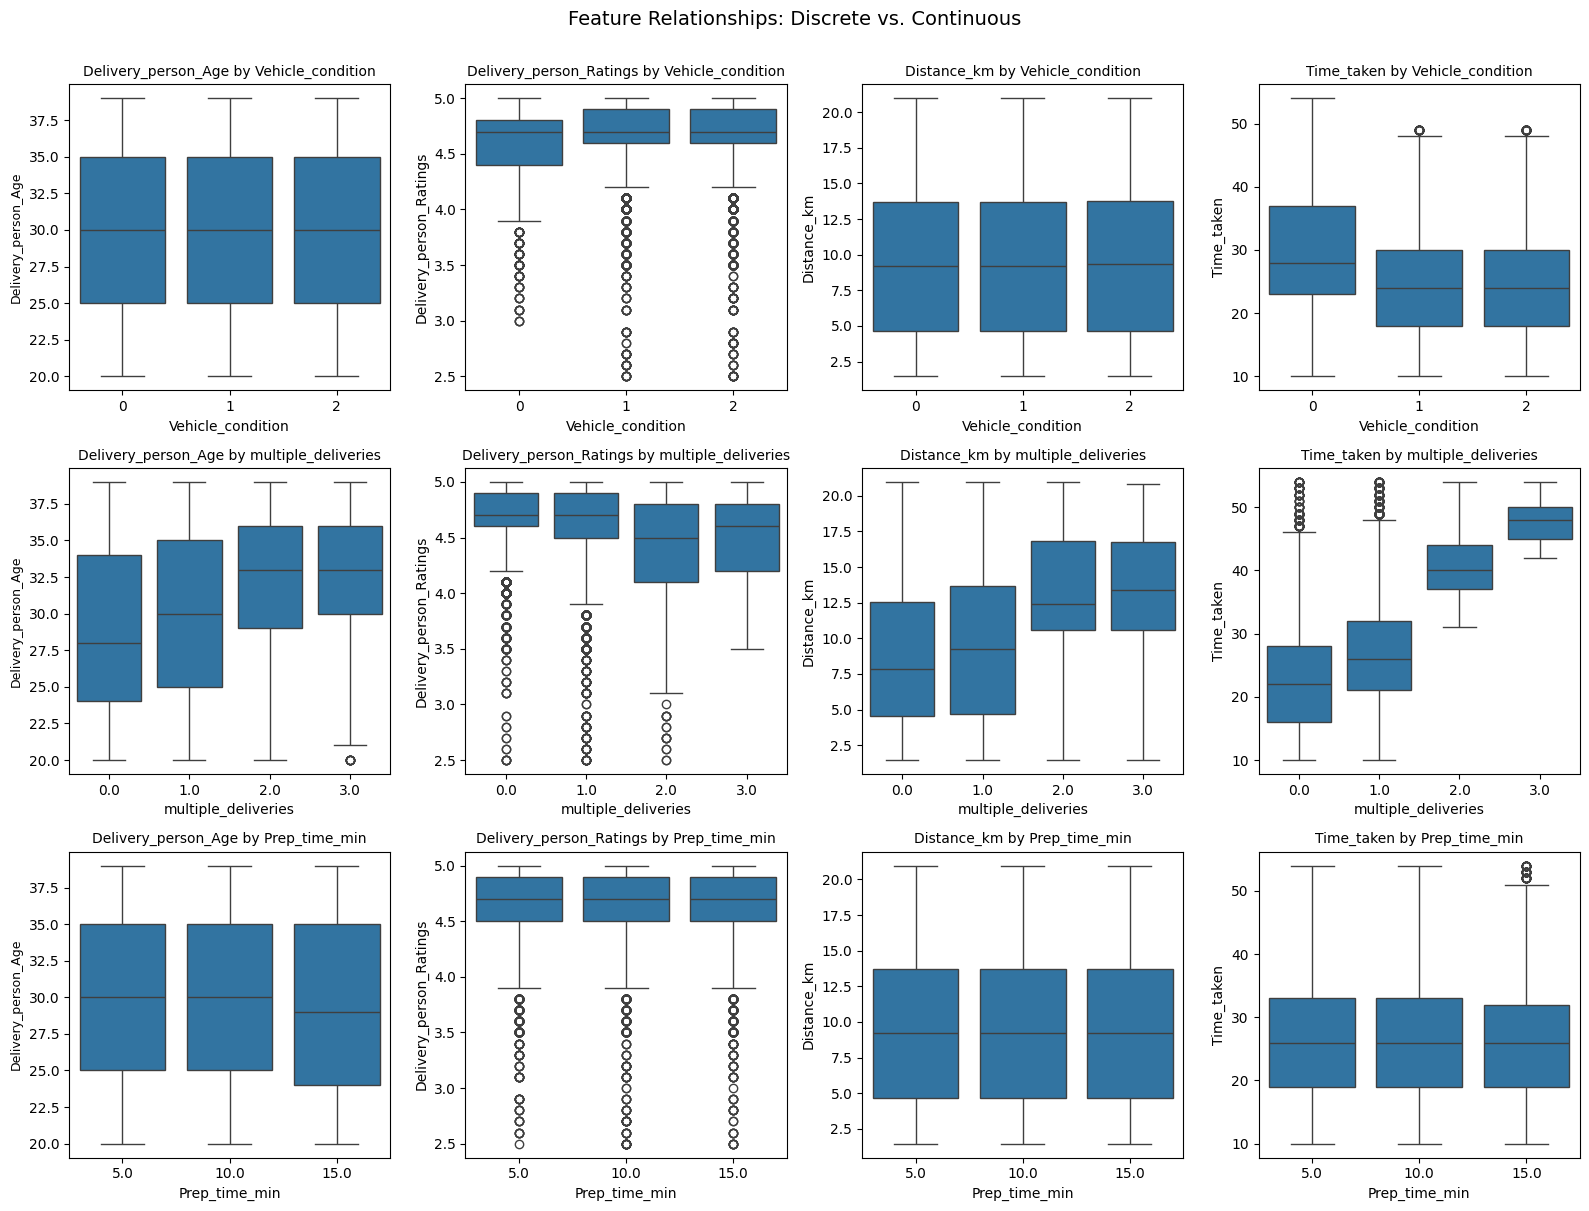

In [122]:
# Feature relationships
# Figure 2: Discrete vs Continuous (box plots)
fig, axs = plt.subplots(n_disc, n_cont, figsize=(4*n_cont, 4*n_disc))

for i, dcol in enumerate(discrete_cols):
    for col, ccol in enumerate(continuous_cols):
        ax = axs[i, col]
        sns.boxplot(x=dcol, y=ccol, data=train_df, ax=ax)
        ax.set_title(f'{ccol} by {dcol}', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'{ccol}', fontsize=9)

fig.suptitle('Feature Relationships: Discrete vs. Continuous', y=1.005, fontsize=14)
plt.tight_layout()
plt.show()

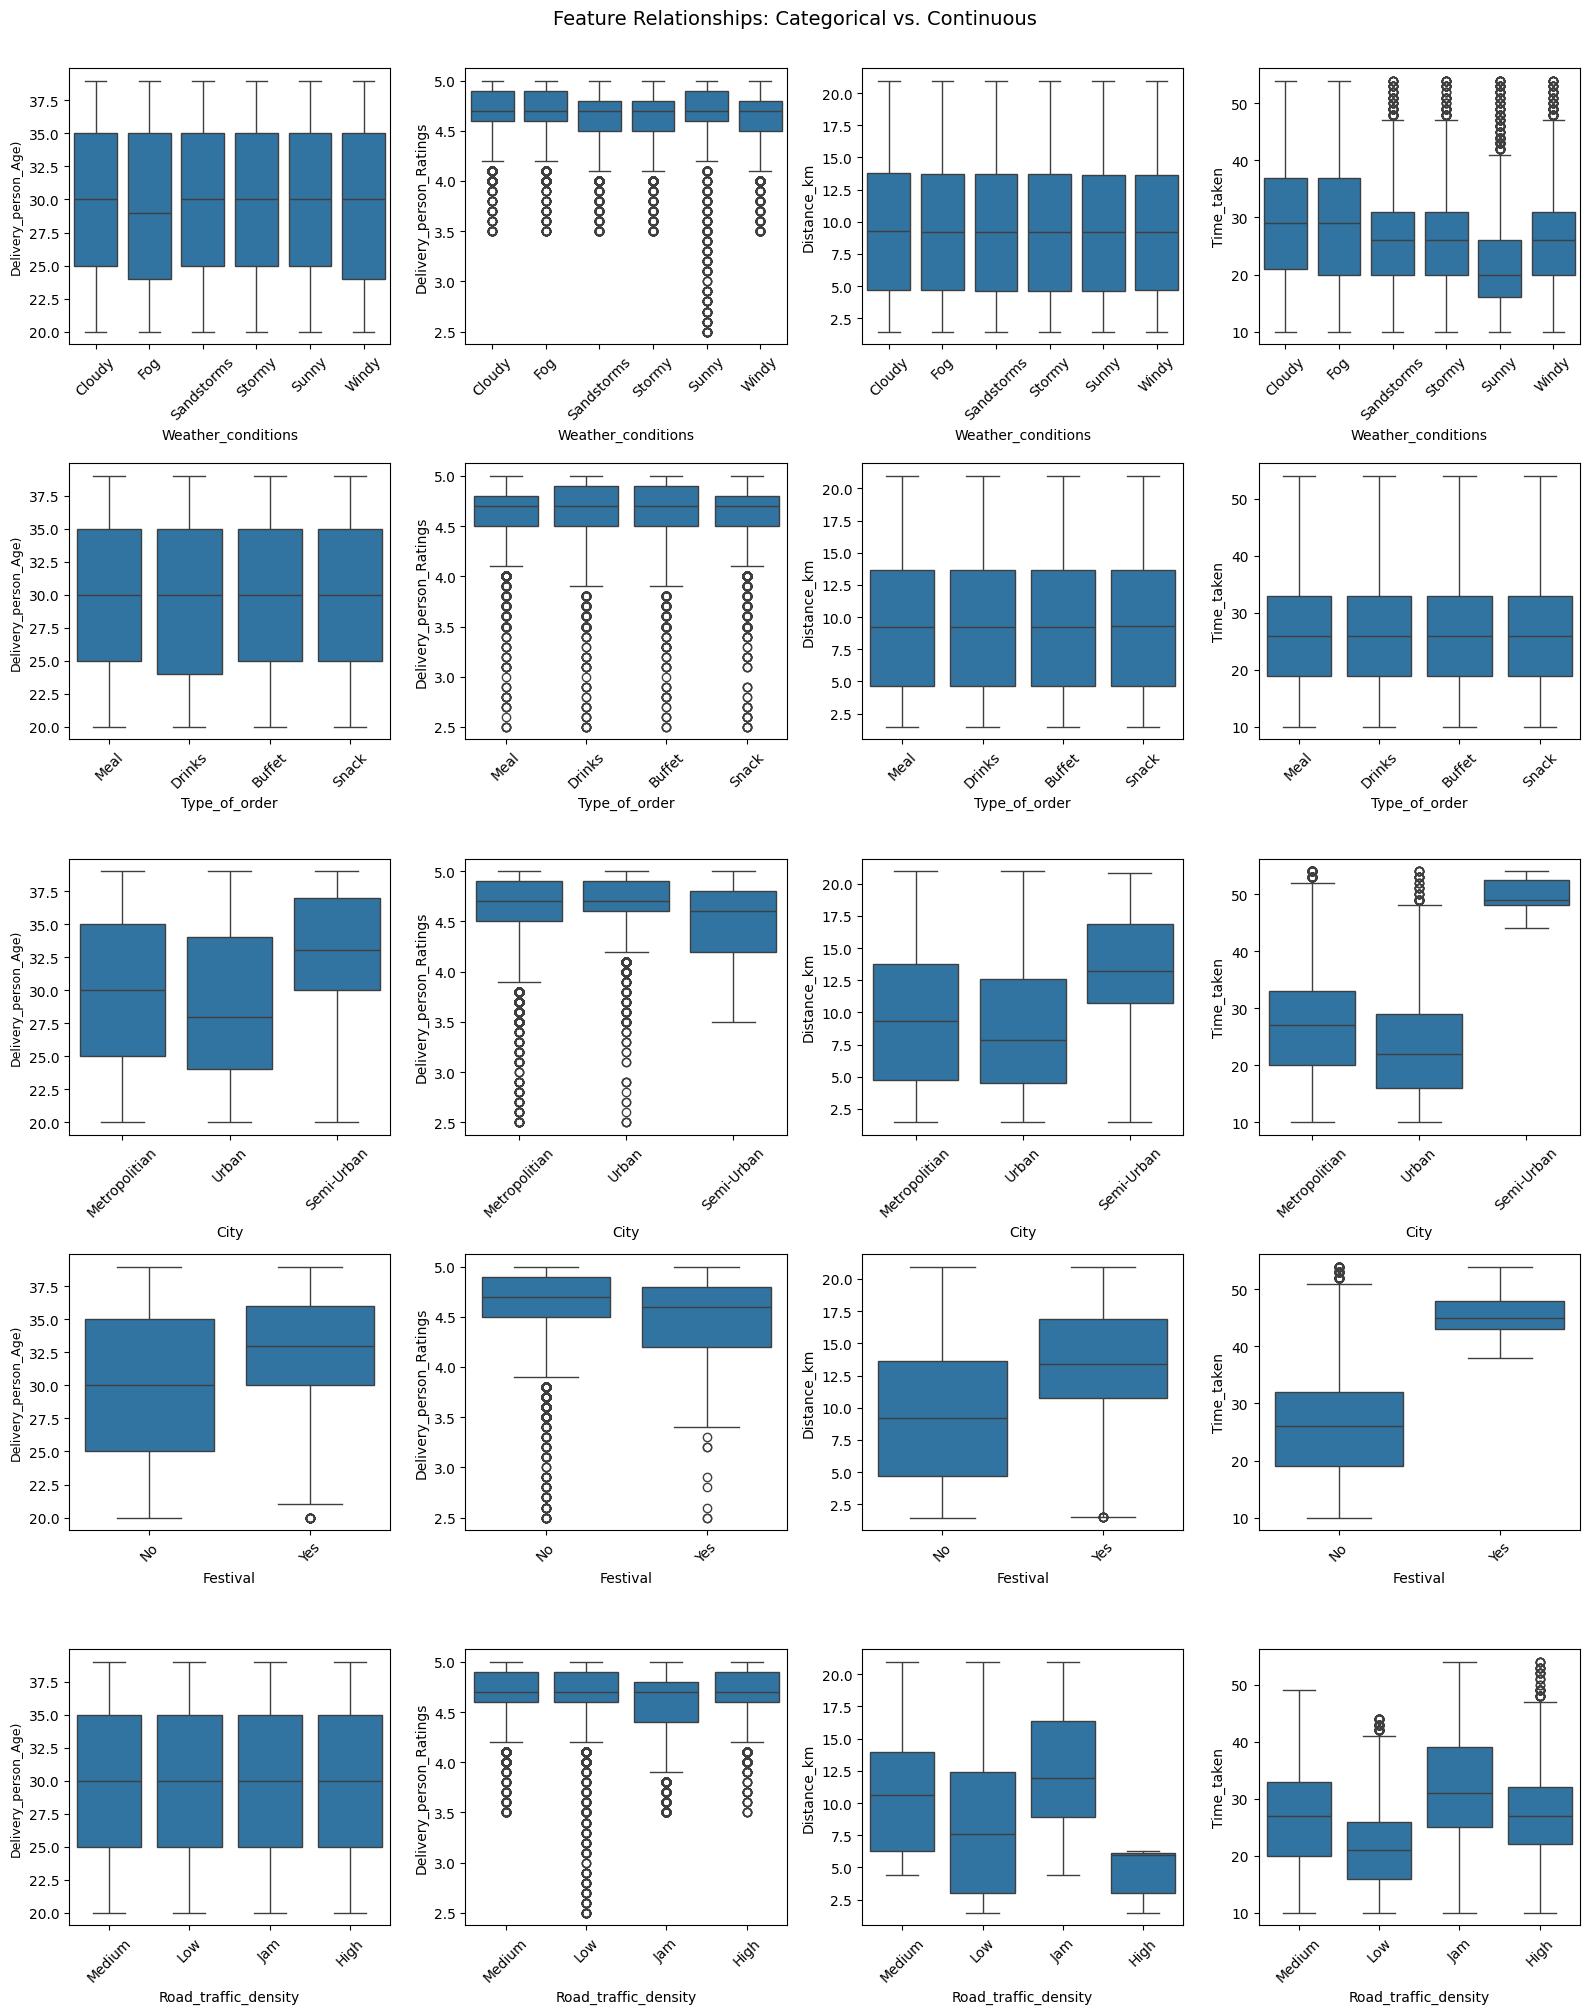

In [123]:
# Figure 3: Categorical vs Continuous (box plots, rotated labels)
fig, axs = plt.subplots(n_cat, n_cont, figsize=(4*n_cont, 4*n_cat))

for i, catcol in enumerate(categorical_cols):
    for col, ccol in enumerate(continuous_cols):
        ax = axs[i, col]
        sns.boxplot(x=catcol, y=ccol, data=train_df, ax=ax)
        ax.tick_params(axis='x', rotation=45)
        if col == 0:
            ax.set_ylabel(f'{ccol})', fontsize=9)

fig.suptitle('Feature Relationships: Categorical vs. Continuous', y=1.005, fontsize=14)
plt.tight_layout()
plt.show()

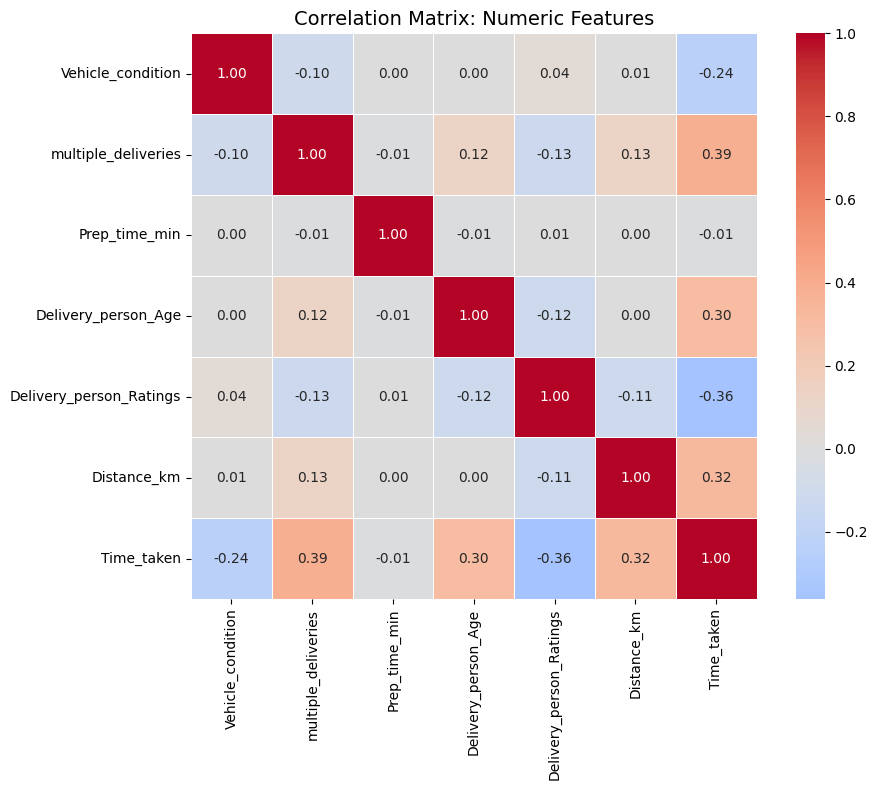

In [158]:
# 3. Correlation matrix
corr_matrix = train_df[discrete_cols + continuous_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

#### 9. Feature Encoding + Scaling

In [125]:
# organize columns
norm_cols = ['Delivery_person_Age', 'Delivery_person_Ratings', 
                 'Distance_km', 'Prep_time_min',
                 'Vehicle_condition', 'multiple_deliveries']
onehot_cols = ['Weather_conditions', 'Type_of_order', 'Type_of_vehicle', 'City']
ordinal_cols = ['Road_traffic_density']
ordinal_order = [['Low', 'Medium', 'High', 'Jam']]

In [126]:
# 1. Binary: label encoding
for df in [X_train_clean, X_test_clean]:
    df['Festival'] = df['Festival'].map({'No': 0, 'Yes': 1})

In [127]:
# 2. Categorical: one-hot encoding + Ordinal encoding + Scaling
preprocessor_norm = ColumnTransformer(transformers=[
    ('num', StandardScaler(), norm_cols),
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
    ('ordinal', OrdinalEncoder(categories=ordinal_order), ordinal_cols),
], remainder='passthrough')

# Only One-hot encoding: categorical + Ordinal encoding (no scaling)
preprocessor_raw = ColumnTransformer(transformers=[
    ('num', 'passthrough', norm_cols), 
    ('onehot', OneHotEncoder(handle_unknown='ignore'), onehot_cols),
    ('ordinal', OrdinalEncoder(categories=ordinal_order), ordinal_cols),
], remainder='passthrough')

# Fit each on train, transform both train/test
X_train_encoded_norm = preprocessor_norm.fit_transform(X_train_clean)
X_test_encoded_norm  = preprocessor_norm.transform(X_test_clean)

X_train_encoded_raw = preprocessor_raw.fit_transform(X_train_clean)
X_test_encoded_raw  = preprocessor_raw.transform(X_test_clean)

# PART 2. Model Training

In [311]:
# KFold split training into 5 sets
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# function to print the model result (out-of-sample: cv)
def print_result_cv(model, in_X, in_y, cv):

    # Cross-validated (out-of-sample, but still only using training data)
    cv_mae_per_fold  = -cross_val_score(model, in_X, in_y, cv=cv, scoring='neg_mean_absolute_error')
    cv_mae  = cv_mae_per_fold.mean()
    cv_mae_std  = cv_mae_per_fold.std()

    cv_rmse_per_fold = -cross_val_score(model, in_X, in_y, cv=cv, scoring='neg_root_mean_squared_error')
    cv_rmse = cv_rmse_per_fold.mean()
    cv_rmse_std = cv_rmse_per_fold.std()

    cv_r2   =  cross_val_score(model, in_X, in_y, cv=cv, scoring='r2').mean()
    cv_mape = -cross_val_score(model, in_X, in_y, cv=cv, scoring='neg_mean_absolute_percentage_error').mean()

    # num_vars = len(model.coef_[model.coef_ != 0]) if hasattr(model, 'coef_') else in_X.shape[1]

    result = {
        'model_name': type(model).__name__,
        'cv_MAE_per_fold': cv_mae_per_fold,
        'cv_MAE': cv_mae,
        'cv_MAE_std': cv_mae_std,
        'cv_RMSE_per_fold': cv_rmse_per_fold,
        'cv_RMSE': cv_rmse,
        'cv_RMSE_std': cv_rmse_std,
        'cv_R2': cv_r2,
        'cv_MAPE': cv_mape,
        'model': model   # keep the fitted model for later use
    }

    summary_cols = ['model_name',
                     'cv_MAE_per_fold', 'cv_MAE', 'cv_MAE_std',
                     'cv_RMSE_per_fold', 'cv_RMSE', 'cv_RMSE_std',
                     'cv_R2', 'cv_MAPE']

    summary_df = pd.DataFrame([{k: result[k] for k in summary_cols}])

    formatters = {
        'cv_MAE': '{:.2f}'.format,
        'cv_RMSE': '{:.2f}'.format,
        'cv_R2': '{:.2%}'.format,
        'cv_MAPE': '{:.2%}'.format,
    }
    print(summary_df.to_string(index=False, formatters=formatters))

    return result

### 1. Linear Regression

#### Baseline Model

In [313]:
reg_cv_result = print_result_cv(LinearRegression(), X_train_encoded_norm, y_train_clean, kf)

      model_name                                                                                 cv_MAE_per_fold cv_MAE  cv_MAE_std                                                                                cv_RMSE_per_fold cv_RMSE  cv_RMSE_std  cv_R2 cv_MAPE
LinearRegression [4.750378308236722, 4.7722414758212715, 4.754815292453752, 4.80112426696705, 4.740752591525448]   4.76    0.021243 [5.963855777775173, 5.980715375464725, 5.967886727079413, 5.991606799664073, 5.929169166500224]    5.97     0.021142 59.15%  20.83%


In [ ]:
reg_final = LinearRegression().fit(X_train_encoded_norm, y_train_clean)

print("Intercept:", reg_final.intercept_)
print("Coefficients:")
feature_names = preprocessor_norm.get_feature_names_out()
coefs = pd.Series(reg_final.coef_, index=feature_names).sort_index()
print(coefs)

Intercept: 26.125112919436017
Coefficients:
num__Delivery_person_Age                    2.201932
num__Delivery_person_Ratings               -2.297261
num__Distance_km                            1.750660
num__Prep_time_min                         -0.011343
num__Vehicle_condition                     -1.762729
num__multiple_deliveries                    1.674891
onehot__City_Metropolitian                 -2.565146
onehot__City_Semi-Urban                     7.007707
onehot__City_Urban                         -4.442561
onehot__Type_of_order_Buffet               -0.023072
onehot__Type_of_order_Drinks               -0.043618
onehot__Type_of_order_Meal                  0.010627
onehot__Type_of_order_Snack                 0.056063
onehot__Type_of_vehicle_electric_scooter    0.452200
onehot__Type_of_vehicle_motorcycle          0.030201
onehot__Type_of_vehicle_scooter            -0.482401
onehot__Weather_conditions_Cloudy           2.359768
onehot__Weather_conditions_Fog              2.501201
on

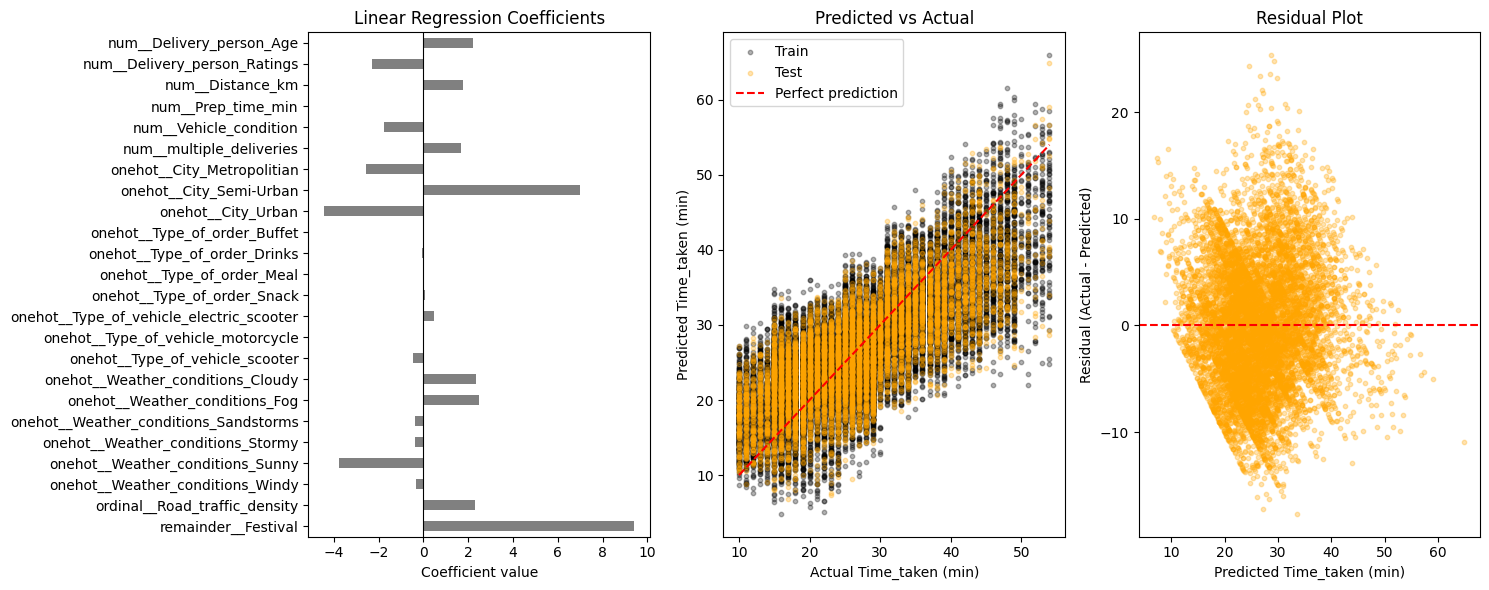

In [263]:
# plots
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

# 1. Coefficients 
coefs.sort_index(ascending=False).plot(kind='barh', ax=axes[0], color='gray')
axes[0].set_xlabel('Coefficient value')
axes[0].set_title('Linear Regression Coefficients')
axes[0].axvline(0, color='black', linewidth=0.8)

# Predict vs. Actual plot
axes[1].scatter(y_train_clean, reg_result['in_pred'], alpha=0.3, s=10, color='black', label='Train ')
axes[1].scatter(y_test_clean, reg_result['out_pred'], alpha=0.3, s=10, color='orange', label='Test')

# Perfect prediction reference line
lims = [min(y_train_clean.min(), y_test_clean.min()), max(y_train_clean.max(), y_test_clean.max())]
axes[1].plot(lims, lims, 'r--', label='Perfect prediction')

axes[1].set_xlabel('Actual Time_taken (min)')
axes[1].set_ylabel('Predicted Time_taken (min)')
axes[1].set_title('Predicted vs Actual')
axes[1].legend()

# Residual plot
residuals_test = y_test_clean - reg_result['out_pred']
axes[2].scatter(reg_result['out_pred'], residuals_test, alpha=0.3, s=10, color='orange')
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_xlabel('Predicted Time_taken (min)')
axes[2].set_ylabel('Residual (Actual - Predicted)')
axes[2].set_title('Residual Plot')

plt.tight_layout()
plt.show()


#### RidgeCV

In [173]:
lambdas = [x/50 for x in range(1,5000)]

ridge_cv = RidgeCV(alphas=lambdas, cv=5, scoring='neg_root_mean_squared_error')
ridge_cv.fit(X_train_encoded_norm, y_train_clean)

print("Best alpha:", ridge_cv.alpha_)
print("Intercept:", ridge_cv.intercept_)
print("Coefficients:", pd.Series(ridge_cv.coef_, index=feature_names))

Best alpha: 3.64
Intercept: 26.057846851178507
Coefficients: num__Delivery_person_Age                    2.202343
num__Delivery_person_Ratings               -2.297435
num__Distance_km                            1.751124
num__Prep_time_min                         -0.011308
num__Vehicle_condition                     -1.763417
num__multiple_deliveries                    1.676189
onehot__Weather_conditions_Cloudy           2.359234
onehot__Weather_conditions_Fog              2.500309
onehot__Weather_conditions_Sandstorms      -0.386925
onehot__Weather_conditions_Stormy          -0.376614
onehot__Weather_conditions_Sunny           -3.763897
onehot__Weather_conditions_Windy           -0.332107
onehot__Type_of_order_Buffet               -0.022972
onehot__Type_of_order_Drinks               -0.043740
onehot__Type_of_order_Meal                  0.010355
onehot__Type_of_order_Snack                 0.056357
onehot__Type_of_vehicle_electric_scooter    0.451728
onehot__Type_of_vehicle_motorcycle    

In [284]:
ridge_fixed = Ridge(alpha=ridge_cv.alpha_)
ridge_result_cv = print_result_cv(ridge_fixed, X_train_encoded_norm, y_train_clean, kf)

model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
     Ridge        24   4.76    5.96 59.22%  20.82%   4.76    5.97 59.15%  20.84%


#### LassoCV

In [179]:
lasso_cv = LassoCV(alphas=lambdas, cv=5)
lasso_cv.fit(X_train_encoded_norm, y_train_clean)

print("Best alpha:", lasso_cv.alpha_)
print("Intercept:", lasso_cv.intercept_)

lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)
print("Coefficients:\n", lasso_coefs[lasso_coefs != 0])

Best alpha: 0.02
Intercept: 23.284308230628376
Coefficients:
 num__Delivery_person_Age                    2.198248
num__Delivery_person_Ratings               -2.288578
num__Distance_km                            1.748355
num__Vehicle_condition                     -1.732195
num__multiple_deliveries                    1.700456
onehot__Weather_conditions_Cloudy           2.595137
onehot__Weather_conditions_Fog              2.734717
onehot__Weather_conditions_Sunny           -3.316289
onehot__Type_of_vehicle_electric_scooter    0.085888
onehot__Type_of_vehicle_scooter            -0.524747
onehot__City_Semi-Urban                     4.212741
onehot__City_Urban                         -1.803168
ordinal__Road_traffic_density               2.330676
remainder__Festival                         8.691537
dtype: float64


In [285]:
lasso_fixed = Lasso(alpha=lasso_cv.alpha_)
lasso_result_cv = print_result_cv(lasso_fixed, X_train_encoded_norm, y_train_clean, kf)

model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
     Lasso        14   4.77    5.97 59.06%  20.86%   4.77    5.98 59.00%  20.88%


### 2. Tree-based

#### Random Forest Regressor

In [ ]:
# Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_encoded_raw, y_train_clean)

           model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE out_MAE out_RMSE out_R2 out_MAPE
RandomForestRegressor        24   1.14    1.43 97.65%   4.84%    3.07     3.84 83.09%   13.07%


<Axes: >

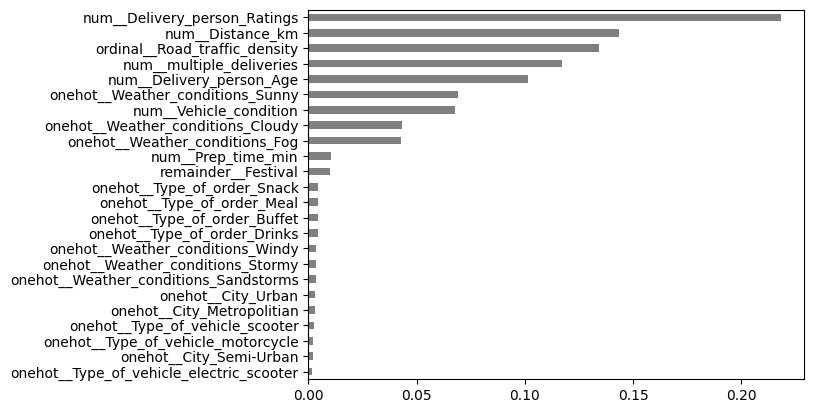

In [230]:
pd.Series(rf.feature_importances_, index=feature_names).sort_values().plot(kind='barh', color='gray')

In [194]:
# CV
# 15min
rf_grid = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_leaf': [1, 5, 10],
}

rf_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_grid,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1      # use all CPU cores — RF grid search is slow, this helps a lot
)

rf_search.fit(X_train_encoded_raw, y_train_clean)   # remember: raw/unscaled for tree models

print("Best params:", rf_search.best_params_)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params: {'max_depth': 20, 'min_samples_leaf': 10, 'n_estimators': 300}
Best CV MAE: 3.775050882158699


In [ ]:
rf_optimal = RandomForestRegressor(max_depth=20, min_samples_leaf=10, n_estimators=300)
rf_optimal.fit(X_train_encoded_raw, y_train_clean)

rf_optimal_result_cv = print_result_cv(rf_optimal, X_train_encoded_raw, y_train_clean, kf)

           model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE out_MAE out_RMSE out_R2 out_MAPE
RandomForestRegressor        24   2.57    3.19 88.33%  10.95%    3.03     3.76 83.78%   12.92%


<Axes: >

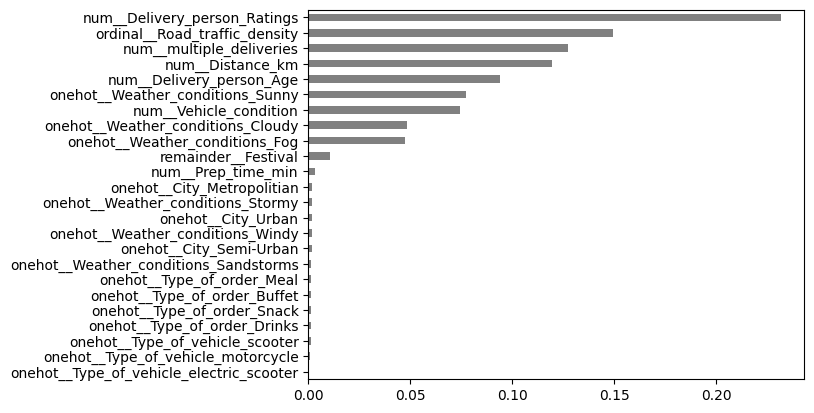

In [231]:
pd.Series(rf_optimal.feature_importances_, index=feature_names).sort_values().plot(kind='barh', color='gray')

#### XGBoost

In [ ]:
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
xgb.fit(X_train_encoded_raw, y_train_clean)

  model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE out_MAE out_RMSE out_R2 out_MAPE
XGBRegressor        24   2.67    3.33 87.28%  11.51%    3.04     3.79 83.50%   13.00%


In [233]:
xgb_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 6, 10],
    'learning_rate': [0.01, 0.1, 0.3],
}

xgb_search = GridSearchCV(
    XGBRegressor(random_state=42), xgb_grid, cv=kf,
    scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1
)
xgb_search.fit(X_train_encoded_raw, y_train_clean)
print("Best XGB params:", xgb_search.best_params_)

best_xgb = xgb_search.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best XGB params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}


In [235]:
xgb_optimal = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb_optimal.fit(X_train_encoded_raw, y_train_clean)

xgb_optimal_result = print_result(xgb_optimal, X_train_encoded_raw, y_train_clean, X_test_encoded_raw, y_test_clean)

  model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE out_MAE out_RMSE out_R2 out_MAPE
XGBRegressor        24   2.90    3.61 85.09%  12.50%    3.04     3.80 83.47%   13.04%


In [292]:
xgb_optimal_result_cv = print_result_cv(xgb_optimal, X_train_encoded_raw, y_train_clean, kf)

  model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
XGBRegressor        24   2.90    3.61 85.09%  12.50%   3.05    3.78 83.59%  13.07%


<Axes: >

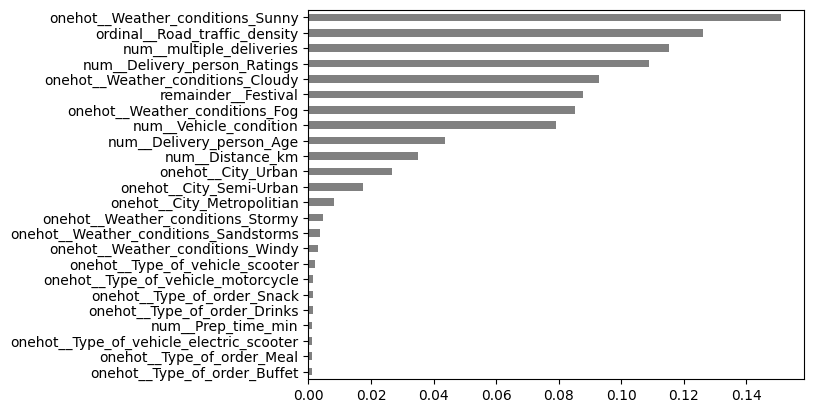

In [237]:
pd.Series(xgb_optimal.feature_importances_, index=feature_names).sort_values().plot(kind='barh', color='gray')

#### LightGBM

In [ ]:
lgbm = LGBMRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train_encoded_raw, y_train_clean)

   model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE out_MAE out_RMSE out_R2 out_MAPE
LGBMRegressor        24   2.81    3.48 86.07%  12.08%    3.02     3.75 83.87%   12.92%


In [243]:
# lgbm_random = RandomizedSearchCV(
#     LGBMRegressor(random_state=42, force_row_wise=True, verbose=-1),
#     param_distributions=lgbm_grid, n_iter=15, cv=kf,
#     scoring='neg_mean_absolute_error', n_jobs=-1, random_state=42
# )
# lgbm_random.fit(X_train_encoded_raw, y_train_clean)

# lgbm_random_result = print_result(lgbm_random, X_train_encoded_raw, y_train_clean, X_test_encoded_raw, y_test_clean)

        model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE out_MAE out_RMSE out_R2 out_MAPE
RandomizedSearchCV        24   2.79    3.44 86.41%  11.99%    3.00     3.71 84.23%   12.80%


In [240]:
lgbm_grid = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, -1],       # -1 means unlimited in LightGBM
    'learning_rate': [0.01, 0.1, 0.3],
    'num_leaves': [15, 31, 63],     # LightGBM-specific, controls tree complexity
}

lgbm_search = GridSearchCV(
    LGBMRegressor(random_state=42, force_row_wise=True, verbose=-1),
    lgbm_grid, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1
)
lgbm_search.fit(X_train_encoded_raw, y_train_clean)

print("Best LGBM params:", lgbm_search.best_params_)
best_lgbm = lgbm_search.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best LGBM params: {'learning_rate': 0.1, 'max_depth': -1, 'n_estimators': 100, 'num_leaves': 63}


In [ ]:
lgbm_optimal = LGBMRegressor(
    n_estimators=100,
    max_depth=-1,
    learning_rate=0.1,
    num_leaves=63,
    random_state=42,
    verbose=-1
)

lgbm_optimal.fit(X_train_encoded_raw, y_train_clean)

   model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE out_MAE out_RMSE out_R2 out_MAPE
LGBMRegressor        24   2.79    3.44 86.41%  11.99%    3.00     3.71 84.23%   12.80%


In [293]:
lgbm_optimal_result_cv = print_result_cv(lgbm_optimal, X_train_encoded_raw, y_train_clean, kf)

   model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
LGBMRegressor        24   2.79    3.44 86.41%  11.99%   2.99    3.71 84.24%  12.79%


<Axes: >

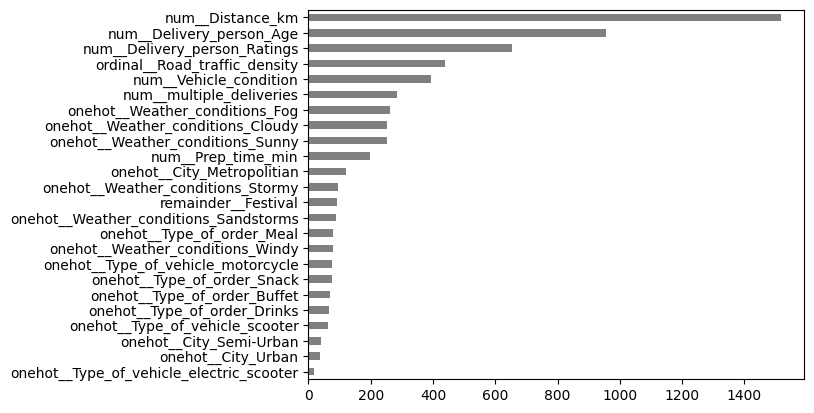

In [239]:
pd.Series(lgbm_optimal.feature_importances_, index=feature_names).sort_values().plot(kind='barh', color='gray')

#### CatBoost

In [ ]:
catboost = CatBoostRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    verbose=0  
)
catboost.fit(X_train_encoded_raw, y_train_clean)


       model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE out_MAE out_RMSE out_R2 out_MAPE
CatBoostRegressor        24   2.92    3.62 84.96%  12.56%    3.01     3.75 83.88%   12.91%


In [246]:
cat_grid = {
    'n_estimators': [100, 300],
    'depth': [4, 6, 8],              # CatBoost calls it "depth" not "max_depth"
    'learning_rate': [0.01, 0.1, 0.3],
    'l2_leaf_reg': [1, 3, 10],       # CatBoost-specific L2 regularization
}

cat_search = GridSearchCV(
    CatBoostRegressor(random_state=42, verbose=0),
    cat_grid, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1
)
cat_search.fit(X_train_encoded_raw, y_train_clean)

print("Best CatBoost params:", cat_search.best_params_)
best_catboost = cat_search.best_estimator_

Fitting 5 folds for each of 54 candidates, totalling 270 fits


Best CatBoost params: {'depth': 8, 'l2_leaf_reg': 10, 'learning_rate': 0.1, 'n_estimators': 300}


In [ ]:
cat_optimal = CatBoostRegressor(
    n_estimators=300, max_depth=8, l2_leaf_reg=10, learning_rate=0.1, verbose=0
)

cat_optimal.fit(X_train_encoded_raw, y_train_clean)


       model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE out_MAE out_RMSE out_R2 out_MAPE
CatBoostRegressor        24   2.78    3.44 86.41%  11.93%    2.97     3.70 84.30%   12.71%


In [ ]:
# Cat native
cat_features = ['Weather_conditions', 'Type_of_order', 'Type_of_vehicle', 'City', 'Road_traffic_density']

cat_native = CatBoostRegressor(n_estimators=300, random_state=42, verbose=0, cat_features=cat_features)
cat_native.fit(X_train_clean, y_train_clean)


       model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE out_MAE out_RMSE out_R2 out_MAPE
CatBoostRegressor        12   2.92    3.62 84.98%  12.49%    2.98     3.71 84.22%   12.73%


In [ ]:
cat_grid = {
    'n_estimators': [100, 300],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.1, 0.3],
    'l2_leaf_reg': [1, 3, 10],
}

cat_native_search = GridSearchCV(
    CatBoostRegressor(random_state=42, verbose=0),   
    cat_grid, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1
)

# Pass cat_features as a fit param — GridSearchCV forwards **fit_params to estimator.fit()
cat_native_search.fit(X_train_clean, y_train_clean, cat_features=cat_features)

print("Best CatBoost native params:", cat_native_search.best_params_)
best_cat_native = cat_native_search.best_estimator_


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best CatBoost native params: {'depth': 8, 'l2_leaf_reg': 1, 'learning_rate': 0.1, 'n_estimators': 300}
       model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE out_MAE out_RMSE out_R2 out_MAPE
CatBoostRegressor        12   2.85    3.53 85.74%  12.22%    2.95     3.66 84.61%   12.60%


In [300]:
class CatBoostNativeWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, cat_features=None, **catboost_params):
        self.cat_features = cat_features
        self.catboost_params = catboost_params

    def fit(self, X, y):   # <-- only takes X, y — matches what print_result_cv calls
        self.model_ = CatBoostRegressor(**self.catboost_params)
        self.model_.fit(X, y, cat_features=self.cat_features, verbose=0)  # cat_features pulled from self, not from the caller
        return self

    def predict(self, X):
        return self.model_.predict(X)


cat_native_wrapped = CatBoostNativeWrapper(
    cat_features=cat_features, random_state=42, verbose=0, **cat_native_search.best_params_
)
cat_native_optimal_result_cv = print_result_cv(cat_native_wrapped, X_train_clean, y_train_clean, kf)

           model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
CatBoostNativeWrapper        12   2.85    3.53 85.74%  12.22%   2.99    3.70 84.25%  12.78%


<Axes: >

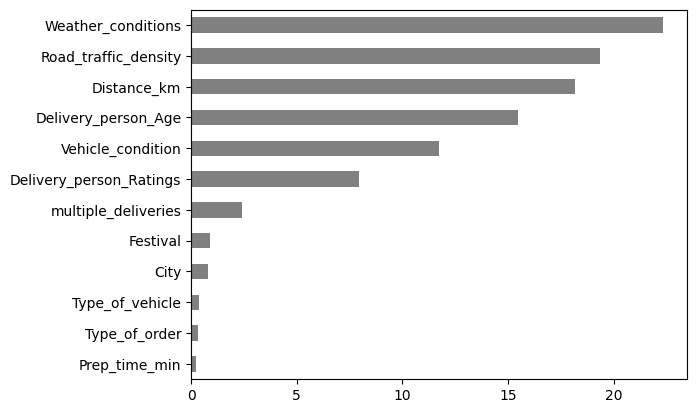

In [266]:
pd.Series(best_cat_native.feature_importances_, index=X_train_clean.columns).sort_values().plot(kind='barh', color='gray')

In [ ]:
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),   # 2 hidden layers: 64 neurons, then 32 neurons
    activation='relu',
    solver='adam',
    alpha=0.001,                    # L2 regularization
    learning_rate_init=0.001,
    max_iter=1000,
    early_stopping=True,
    random_state=42
)

mlp.fit(X_train_encoded_norm, y_train_clean)   # scaled data required


  model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE out_MAE out_RMSE out_R2 out_MAPE
MLPRegressor        24   3.00    3.74 83.93%  12.91%    3.15     3.92 82.35%   13.53%


Converged in 154 iterations
Final loss: 7.0674


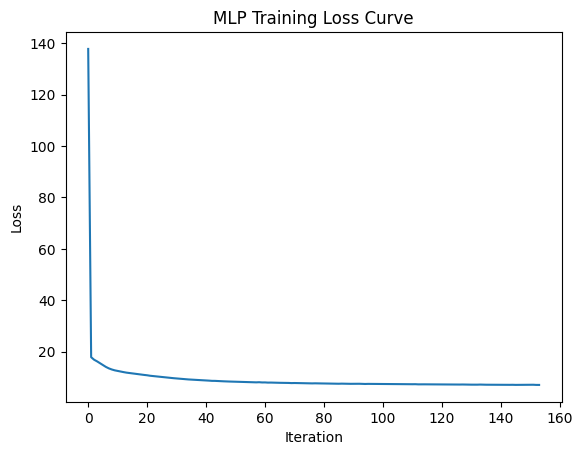

In [256]:
print(f"Converged in {mlp.n_iter_} iterations")
print(f"Final loss: {mlp.loss_:.4f}")

# Plot the loss curve to visually confirm it's actually converging
plt.plot(mlp.loss_curve_)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Training Loss Curve')
plt.show()

In [ ]:
mlp_grid = {
    'hidden_layer_sizes': [(32, 16), (64, 32), (128, 64), (100, 50)],
    'alpha': [0.0001, 0.001, 0.01],
}

mlp_search = GridSearchCV(
    MLPRegressor(random_state=42, max_iter=1000, early_stopping=True, solver='adam'),
    mlp_grid, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1
)
mlp_search.fit(X_train_encoded_norm, y_train_clean)

print("Best architecture:", mlp_search.best_params_)
best_mlp = mlp_search.best_estimator_


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best architecture: {'alpha': 0.01, 'hidden_layer_sizes': (128, 64)}
  model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE out_MAE out_RMSE out_R2 out_MAPE
MLPRegressor        24   2.88    3.59 85.22%  12.15%    3.14     3.90 82.53%   13.28%


In [303]:
mlp_optimal_result_cv = print_result_cv(best_mlp, X_train_encoded_norm, y_train_clean, kf)

  model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
MLPRegressor        24   2.88    3.59 85.22%  12.15%   3.18    3.96 82.03%  13.55%


### 4. Stacking

In [ ]:
# 1. Out-of-fold predictions on TRAINING data (avoids leakage into the meta-model)
oof_cat = cross_val_predict(
    CatBoostRegressor(random_state=42, verbose=0, **cat_native_search.best_params_),
    X_train_clean, y_train_clean, cv=kf, params={'cat_features': cat_features}
)
oof_lgbm = cross_val_predict(
    LGBMRegressor(random_state=42, force_row_wise=True, verbose=-1, **lgbm_search.best_params_),
    X_train_encoded_raw, y_train_clean, cv=kf
)
oof_xgb = cross_val_predict(
    XGBRegressor(random_state=42, **xgb_search.best_params_),
    X_train_encoded_raw, y_train_clean, cv=kf
)
oof_ridge = cross_val_predict(
    Ridge(alpha=ridge_cv.alpha_),
    X_train_encoded_norm, y_train_clean, cv=kf
)

meta_X_train = np.column_stack([oof_cat, oof_lgbm, oof_xgb, oof_ridge])

# 2. Build meta-features for the test set using the fully-fitted base models
meta_X_test = np.column_stack([
    best_cat_native.predict(X_test_clean),
    best_lgbm.predict(X_test_encoded_raw),
    best_xgb.predict(X_test_encoded_raw),
    ridge_cv.predict(X_test_encoded_norm),
])

# 3. Fit the meta-model
meta_model = Ridge(alpha=1.0)
meta_model.fit(meta_X_train, y_train_clean)

# 4. Predictions
stacked_pred_train = meta_model.predict(meta_X_train)
stacked_pred_test = meta_model.predict(meta_X_test)

stacking_result = {
    'model_name': 'Stacked_Ridge',
    'num_vars': 4,   # number of base models feeding the meta-model
    'in_MAE': mean_absolute_error(y_train_clean, stacked_pred_train),
    'in_RMSE': root_mean_squared_error(y_train_clean, stacked_pred_train),
    'in_R2': r2_score(y_train_clean, stacked_pred_train),
    'in_MAPE': mean_absolute_percentage_error(y_train_clean, stacked_pred_train),
    'out_MAE': mean_absolute_error(y_test_clean, stacked_pred_test),
    'out_RMSE': root_mean_squared_error(y_test_clean, stacked_pred_test),
    'out_R2': r2_score(y_test_clean, stacked_pred_test),
    'out_MAPE': mean_absolute_percentage_error(y_test_clean, stacked_pred_test),
    'in_pred': stacked_pred_train,
    'out_pred': stacked_pred_test
}

In [277]:
print(dict(zip(['catboost', 'lgbm', 'xgb', 'ridge'], meta_model.coef_)))

{'catboost': np.float64(0.7627243934213864), 'lgbm': np.float64(0.3922571957731821), 'xgb': np.float64(-0.13949598518350234), 'ridge': np.float64(-0.015476169282793181)}


# PART 3. Model Evaluation

### 1. All model results

In [304]:
all_results_cv = [
    reg_result_cv, ridge_result_cv, lasso_result_cv, 
    rf_optimal_result_cv, xgb_optimal_result_cv, lgbm_optimal_result_cv, cat_native_optimal_result_cv,
    mlp_optimal_result_cv#,
    # stacking_result
]

summary_cols_cv = ['model_name', 'num_vars', 
                 'in_MAE', 'in_RMSE', 'in_R2', 'in_MAPE',
                 'cv_MAE', 'cv_RMSE', 'cv_R2', 'cv_MAPE']

all_results_cv = pd.DataFrame(all_results_cv)[summary_cols_cv]

formatters_cv = {
    'in_MAE': '{:.2f}'.format, 'cv_MAE': '{:.2f}'.format,
    'in_RMSE': '{:.2f}'.format, 'cv_RMSE': '{:.2f}'.format,
    'in_R2': '{:.2%}'.format, 'cv_R2': '{:.2%}'.format,
    'in_MAPE': '{:.2%}'.format, 'cv_MAPE': '{:.2%}'.format,
}

print(all_results_cv.to_string(index=False, formatters=formatters_cv))

           model_name  num_vars in_MAE in_RMSE  in_R2 in_MAPE cv_MAE cv_RMSE  cv_R2 cv_MAPE
     LinearRegression        24   4.76    5.96 59.22%  20.82%   4.76    5.97 59.15%  20.83%
                Ridge        24   4.76    5.96 59.22%  20.82%   4.76    5.97 59.15%  20.84%
                Lasso        14   4.77    5.97 59.06%  20.86%   4.77    5.98 59.00%  20.88%
RandomForestRegressor        24   2.57    3.19 88.31%  10.96%   3.04    3.78 83.66%  12.97%
         XGBRegressor        24   2.90    3.61 85.09%  12.50%   3.05    3.78 83.59%  13.07%
        LGBMRegressor        24   2.79    3.44 86.41%  11.99%   2.99    3.71 84.24%  12.79%
CatBoostNativeWrapper        12   2.85    3.53 85.74%  12.22%   2.99    3.70 84.25%  12.78%
         MLPRegressor        24   2.88    3.59 85.22%  12.15%   3.18    3.96 82.03%  13.55%
